# Final Opportunity Analysis
## Sugar Alternative Whitespace Analysis

**Objective:** Combine all 4 KPIs to identify top 3 market opportunities

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Part 1: Loading Data

In [ ]:
from google.colab import files

# Uploading initial KPI results
print("Upload initial_kpi_results.csv:")
uploaded = files.upload()

Upload initial_kpi_results.csv:


Saving initial_kpi_results.csv to initial_kpi_results.csv


In [ ]:
# Uploading Google Trends data
print("\nUpload category_trends.csv:")
uploaded = files.upload()


Upload category_trends.csv:


Saving category_trends.csv to category_trends.csv


In [ ]:
print("\nUpload sweetener_trends.csv:")
uploaded = files.upload()


Upload sweetener_trends.csv:


Saving sweetener_trends.csv to sweetener_trends.csv


In [ ]:
# Loading files
df_kpis = pd.read_csv('initial_kpi_results.csv')
df_category_trends = pd.read_csv('category_trends.csv')
df_sweetener_trends = pd.read_csv('sweetener_trends.csv')

print(f"Initial KPIs: {len(df_kpis)} categories")
print(f"Category trends: {len(df_category_trends)} categories")
print(f"Sweetener trends: {len(df_sweetener_trends)} sweeteners")

Initial KPIs: 65 categories
Category trends: 10 categories
Sweetener trends: 5 sweeteners


## Part 2: KPI 4 - Social Velocity


In [ ]:
# Formula: (interest_score * 0.7) + (growth_score * 0.3)
# Interest normalized to 0-100, Growth mapped from [-50, 50] to [0, 100]

print("Calculating Social Velocity:\n")

# Normalizing interest score (already 0-100 from Google Trends)
df_category_trends['interest_score'] = df_category_trends['avg_interest']

# Mapping growth rate from [-50, 50] to [0, 100]
# Formula: (growth + 50) / 100 * 100 = growth + 50
df_category_trends['growth_score'] = df_category_trends['growth_rate'].apply(
    lambda x: max(0, min(100, x + 50))  # Clamp between 0-100
)

# Calculating Social Velocity
df_category_trends['social_velocity'] = (
    df_category_trends['interest_score'] * 0.7 +
    df_category_trends['growth_score'] * 0.3
)

print("Top 5 categories by Social Velocity:")
print(df_category_trends.nlargest(5, 'social_velocity')[['category', 'avg_interest', 'growth_rate', 'social_velocity']])

Calculating Social Velocity:

Top 5 categories by Social Velocity:
                     category  avg_interest  growth_rate  social_velocity
8   Ice Cream & Frozen Yogurt          48.7           -3            48.19
6            Wholesome Snacks          43.1            7            47.27
3                   Chocolate          42.5            4            45.95
9  Cakes Cupcakes Snack Cakes          37.2           -4            39.84
0                       Candy          29.5           11            38.95


## Part 3: Merging KPIs

In [ ]:
print("Merging all KPIs:\n")

# Removing commas from both files to match
df_kpis['category'] = df_kpis['category'].str.replace(',', '')
df_category_trends['category'] = df_category_trends['category'].str.replace(',', '')

# Merging category trends with initial KPIs
final_analysis = df_kpis.merge(
    df_category_trends[['category', 'avg_interest', 'growth_rate', 'social_velocity']],
    on='category',
    how='left'
)

# Filling NaN for categories not in top 10
final_analysis['social_velocity'] = final_analysis['social_velocity'].fillna(0)

print(f"Merged data: {len(final_analysis)} categories")
print("\nColumns:", list(final_analysis.columns))

Merging all KPIs:

Merged data: 65 categories

Columns: ['category', 'avg_sugar', 'sugar_load', 'market_gap', 'market_size', 'sugar_load_norm', 'gap_norm', 'size_norm', 'opportunity_score', 'avg_interest', 'growth_rate', 'social_velocity']


## Part 4: Final Opportunity Score


In [ ]:
# Formula: (sugar_load * 0.30) + (market_gap * 0.35) + (market_size * 0.20) + (social_velocity * 0.15)

print("Calculating final opportunity scores:\n")

# Normalizing Social Velocity to 0-100
max_velocity = final_analysis['social_velocity'].max()
if max_velocity > 0:
    final_analysis['social_velocity_norm'] = (final_analysis['social_velocity'] / max_velocity) * 100
else:
    final_analysis['social_velocity_norm'] = 0

# Calculating final opportunity score
final_analysis['final_opportunity_score'] = (
    final_analysis['sugar_load_norm'] * 0.30 +
    final_analysis['gap_norm'] * 0.35 +
    final_analysis['size_norm'] * 0.20 +
    final_analysis['social_velocity_norm'] * 0.15
)

# Sorting by final score
final_analysis = final_analysis.sort_values('final_opportunity_score', ascending=False).reset_index(drop=True)

print("KPI weights:")
print("  Sugar Load: 30%")
print("  Market Gap: 35%")
print("  Market Size: 20%")
print("  Social Velocity: 15%")

print("\nTop 20 opportunities:")
final_analysis[['category', 'sugar_load', 'market_gap', 'market_size', 'social_velocity', 'final_opportunity_score']].head(20)

Calculating final opportunity scores:

KPI weights:
  Sugar Load: 30%
  Market Gap: 35%
  Market Size: 20%
  Social Velocity: 15%

Top 20 opportunities:


,category,sugar_load,market_gap,market_size,social_velocity,final_opportunity_score
0,Candy,1.195769,89.865433,2378,38.95,93.076581
1,Chocolate,0.895654,86.714542,1114,45.95,76.258313
2,Wholesome Snacks,0.830719,98.756906,724,47.27,76.056870
3,Popcorn Peanuts Seeds & Related Snacks,0.370087,98.400984,2439,37.57,75.419601
4,Jam Jelly & Fruit Spreads,0.983711,98.319328,357,36.22,73.293115
5,Baking Decorations & Dessert Toppings,1.114540,98.017621,454,22.30,72.932368
6,Cookies & Biscuits,0.660149,94.207955,1433,36.79,72.737171
7,Ice Cream & Frozen Yogurt,0.424203,89.597523,1615,48.19,70.244877
8,Cakes Cupcakes Snack Cakes,0.647361,87.278107,1014,39.84,67.504436
9,Fruit Prepared/Processed,0.867521,100.000000,38,25.17,64.910988


## Part 5: Priority Tiers


In [ ]:
print("Assigning priority tiers:\n")

# Defining priority tiers
def assign_priority(score):
    if score >= 75:
        return 'HIGH'
    elif score >= 60:
        return 'MEDIUM'
    elif score >= 45:
        return 'LOW'
    else:
        return 'HOLD'

final_analysis['priority'] = final_analysis['final_opportunity_score'].apply(assign_priority)

# Counting by priority
priority_counts = final_analysis['priority'].value_counts()
print("Categories by priority:")
for priority in ['HIGH', 'MEDIUM', 'LOW', 'HOLD']:
    count = priority_counts.get(priority, 0)
    print(f"  {priority}: {count}")

Assigning priority tiers:

Categories by priority:
  HIGH: 4
  MEDIUM: 6
  LOW: 16
  HOLD: 39


## Part 6: Top 3 Recommendations

In [ ]:
print("Top 3 investment opportunities:\n")

top_3 = final_analysis.head(3)

for idx, row in top_3.iterrows():
    print(f"\n{'='*60}")
    print(f"#{idx+1}: {row['category']}")
    print(f"{'='*60}")
    print(f"Final Opportunity Score: {row['final_opportunity_score']:.1f}/100")
    print(f"Priority: {row['priority']}")
    print(f"\nKPI Breakdown:")
    print(f"  Sugar Load: {row['sugar_load']:.2f} ({row['avg_sugar']:.1f}g per 100g)")
    print(f"  Market Gap: {row['market_gap']:.1f}%")
    print(f"  Market Size: {row['market_size']:.0f} products")
    if pd.notna(row['social_velocity']):
        print(f"  Social Velocity: {row['social_velocity']:.1f}")
        print(f"    - Search Interest: {row['avg_interest']:.1f}")
        print(f"    - Growth Rate: {row['growth_rate']:+.1f}%")
    print(f"\nRecommendation:")
    if row['final_opportunity_score'] >= 75:
        print(f"  INVEST NOW - High sugar load, significant gap, strong market")
    elif row['final_opportunity_score'] >= 60:
        print(f"  STRONG OPPORTUNITY - Good fundamentals, favorable conditions")
    else:
        print(f"  MONITOR - Decent opportunity but lower priority")

Top 3 investment opportunities:


#1: Candy
Final Opportunity Score: 93.1/100
Priority: HIGH

KPI Breakdown:
  Sugar Load: 1.20 (59.8g per 100g)
  Market Gap: 89.9%
  Market Size: 2378 products
  Social Velocity: 39.0
    - Search Interest: 29.5
    - Growth Rate: +11.0%

Recommendation:
  INVEST NOW - High sugar load, significant gap, strong market

#2: Chocolate
Final Opportunity Score: 76.3/100
Priority: HIGH

KPI Breakdown:
  Sugar Load: 0.90 (44.8g per 100g)
  Market Gap: 86.7%
  Market Size: 1114 products
  Social Velocity: 45.9
    - Search Interest: 42.5
    - Growth Rate: +4.0%

Recommendation:
  INVEST NOW - High sugar load, significant gap, strong market

#3: Wholesome Snacks
Final Opportunity Score: 76.1/100
Priority: HIGH

KPI Breakdown:
  Sugar Load: 0.83 (41.5g per 100g)
  Market Gap: 98.8%
  Market Size: 724 products
  Social Velocity: 47.3
    - Search Interest: 43.1
    - Growth Rate: +7.0%

Recommendation:
  INVEST NOW - High sugar load, significant gap, strong marke

## Part 7: Sweetener Analysis

In [ ]:
print("Sweetener momentum analysis:\n")

# Calculating sweetener scores
df_sweetener_trends['interest_score'] = df_sweetener_trends['avg_interest']
df_sweetener_trends['growth_score'] = df_sweetener_trends['growth_rate'].apply(
    lambda x: max(0, min(100, x + 50))
)
df_sweetener_trends['momentum_score'] = (
    df_sweetener_trends['interest_score'] * 0.6 +
    df_sweetener_trends['growth_score'] * 0.4
)

df_sweetener_trends = df_sweetener_trends.sort_values('momentum_score', ascending=False)

print("Sweetener rankings:")
for idx, row in df_sweetener_trends.iterrows():
    print(f"\n{row['sweetener'].title()}:")
    print(f"  Interest: {row['avg_interest']:.1f}")
    print(f"  Growth: {row['growth_rate']:+.1f}%")
    print(f"  Momentum Score: {row['momentum_score']:.1f}")

    if row['growth_rate'] > 0:
        print(f"  Status: ✓ GROWING")
    else:
        print(f"  Status: ✗ DECLINING")

Sweetener momentum analysis:

Sweetener rankings:

Stevia:
  Interest: 75.9
  Growth: -10.0%
  Momentum Score: 61.5
  Status: ✗ DECLINING

Monk Fruit:
  Interest: 43.4
  Growth: +2.3%
  Momentum Score: 47.0
  Status: ✓ GROWING

Allulose:
  Interest: 29.5
  Growth: -3.2%
  Momentum Score: 36.4
  Status: ✗ DECLINING

Sucralose:
  Interest: 35.7
  Growth: -14.2%
  Momentum Score: 35.7
  Status: ✗ DECLINING

Erythritol:
  Interest: 29.2
  Growth: -4.7%
  Momentum Score: 35.6
  Status: ✗ DECLINING


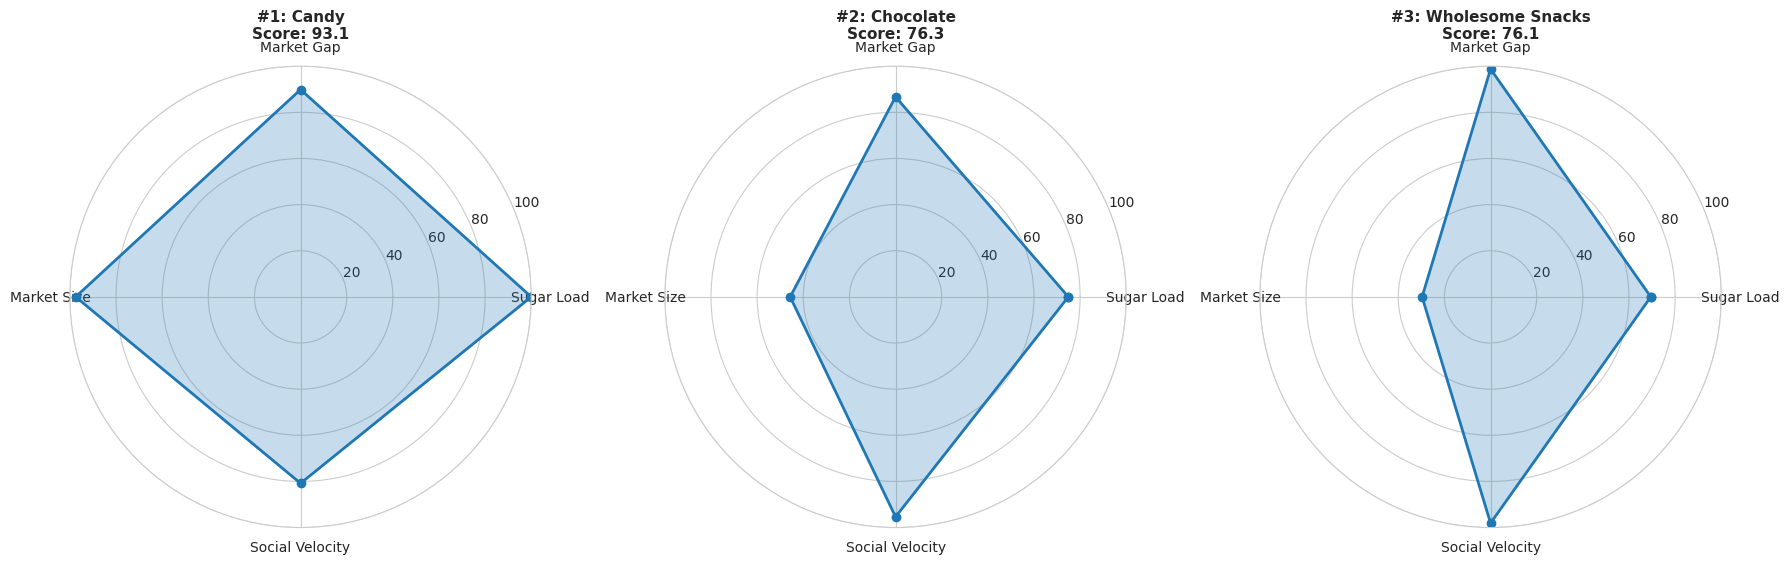

In [ ]:
# Radar chart for top 3
import numpy as np
from math import pi

categories_radar = ['Sugar Load', 'Market Gap', 'Market Size', 'Social Velocity']
N = len(categories_radar)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(projection='polar'))

for idx, ax in enumerate(axes):
    row = top_3.iloc[idx]

    values = [
        row['sugar_load_norm'],
        row['gap_norm'],
        row['size_norm'],
        row['social_velocity_norm']
    ]
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories_radar)
    ax.set_ylim(0, 100)
    ax.set_title(f"#{idx+1}: {row['category'][:30]}\nScore: {row['final_opportunity_score']:.1f}",
                 size=11, weight='bold', pad=20)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Saving full analysis
final_analysis.to_csv('final_opportunity_analysis.csv', index=False)
print("Saved: final_opportunity_analysis.csv")

# Saving top 10
top_10 = final_analysis.head(10)
top_10.to_csv('top_10_opportunities.csv', index=False)
print("Saved: top_10_opportunities.csv")

# Saving sweetener analysis
df_sweetener_trends.to_csv('sweetener_momentum_summary.csv', index=False)
print("Saved: sweetener_momentum_summary.csv")

# Downloading files
files.download('final_opportunity_analysis.csv')
files.download('top_10_opportunities.csv')
files.download('sweetener_momentum_summary.csv')

print("\nFiles downloaded")

Saved: final_opportunity_analysis.csv
Saved: top_10_opportunities.csv
Saved: sweetener_momentum_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Files downloaded


In [ ]:
print("\nFinal analysis complete\n")
print(f"Total categories analyzed: {len(final_analysis)}")
print(f"\nPriority breakdown:")
for priority in ['HIGH', 'MEDIUM', 'LOW', 'HOLD']:
    count = (final_analysis['priority'] == priority).sum()
    print(f"  {priority}: {count}")

print(f"\n4 KPIs calculated:")
print("  1. Sugar Load (30%)")
print("  2. Market Gap (35%)")
print("  3. Market Size (20%)")
print("  4. Social Velocity (15%)")

print("\nTop 3 recommendations:")
for idx, row in top_3.iterrows():
    print(f"\n{idx+1}. {row['category']}")
    print(f"   Score: {row['final_opportunity_score']:.1f}/100")
    print(f"   Priority: {row['priority']}")

print("\nNext steps: PostgreSQL database, ML model, Tableau dashboard")


Final analysis complete

Total categories analyzed: 65

Priority breakdown:
  HIGH: 4
  MEDIUM: 6
  LOW: 16
  HOLD: 39

4 KPIs calculated:
  1. Sugar Load (30%)
  2. Market Gap (35%)
  3. Market Size (20%)
  4. Social Velocity (15%)

Top 3 recommendations:

1. Candy
   Score: 93.1/100
   Priority: HIGH

2. Chocolate
   Score: 76.3/100
   Priority: HIGH

3. Wholesome Snacks
   Score: 76.1/100
   Priority: HIGH

Next steps: PostgreSQL database, ML model, Tableau dashboard
